# RAG Evaluation Pipeline
## Đánh giá tự động RAG với LLM-as-a-Judge

Notebook này thực hiện đánh giá tự động chất lượng của 3 mô hình LLM khác nhau trong hệ thống RAG:
- **Llama 3.1 8B Instant** (Nhanh)
- **Llama 3.3 70B Versatile** (Mạnh)
- **Groq Compound Mini** (Cân bằng)

**Phương pháp:** Sử dụng 50 câu hỏi test và một mô hình LLM mạnh làm "Judge" để chấm điểm câu trả lời.

## 1. Import Required Libraries

In [100]:
# Thư viện cơ bản
import os
import time
import json
from datetime import datetime
from typing import Dict, List, Tuple

# Thư viện xử lý dữ liệu và visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ✅ THÊM MỚI: Thư viện retry
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

# LangChain và ChromaDB
import chromadb
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

# ✅ Định nghĩa thư mục lưu kết quả evaluation
EVAL_DIR = "evaluation"
os.makedirs(EVAL_DIR, exist_ok=True)

# Cập nhật CSV checkpoint để lưu trong thư mục evaluation
# CSV_CHECKPOINT = os.path.join(EVAL_DIR, "evaluation_results.csv")
CSV_CHECKPOINT = os.path.join(EVAL_DIR, "evaluation_results_Alibaba.csv")


print("✅ Đã import thành công (bao gồm tenacity cho retry logic).")

✅ Đã import thành công (bao gồm tenacity cho retry logic).


## 2. Initialize Models and Load ChromaDB

In [101]:
# Load biến môi trường
from dotenv import load_dotenv
load_dotenv(override=True) # Tải biến môi trường từ file .env (ghi đè giá trị nếu biến đã tồn tại)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

if not os.environ.get("GROQ_API_KEY"):
    raise ValueError("❌ Không tìm thấy GROQ_API_KEY trong file .env!")

print("✅ Đã load GROQ_API_KEY từ file .env.")

✅ Đã load GROQ_API_KEY từ file .env.


In [102]:
# 1. Khởi tạo Embedding Model
embedding_model = HuggingFaceEmbeddings(
    # model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    # model_kwargs={'device': 'cpu'},
    model_name="Alibaba-NLP/gte-multilingual-base",
    model_kwargs={'device': 'cpu', 'trust_remote_code': True},
    encode_kwargs={'normalize_embeddings': True}
)
print("✅ Đã khởi tạo Embedding Model (Alibaba-NLP/gte-multilingual-base).")

# 2. Load ChromaDB Collection
db_path = "./chroma_db"
collection_name = "academic_regulations"

vectorstore = Chroma(
    persist_directory=db_path,
    embedding_function=embedding_model,
    collection_name=collection_name
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

print(f"✅ Đã load ChromaDB từ '{db_path}' (collection: '{collection_name}')")
print(f"📚 Số lượng chunks trong DB: {vectorstore._collection.count()}")

Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Đã khởi tạo Embedding Model (Alibaba-NLP/gte-multilingual-base).
✅ Đã load ChromaDB từ './chroma_db' (collection: 'academic_regulations')
📚 Số lượng chunks trong DB: 1926


In [103]:
# 3. Khởi tạo 3 LLM trả lời câu hỏi (cần đánh giá)
llm_models = {
    "Llama 3.1 8B": ChatGroq(model="llama-3.1-8b-instant", temperature=0),
    "Llama 3.3 70B": ChatGroq(model="llama-3.3-70b-versatile", temperature=0),
    "Groq Compound Mini": ChatGroq(model="groq/compound-mini", temperature=0)
}

print("✅ Đã khởi tạo 3 mô hình LLM trả lời câu hỏi (cần đánh giá):")
for name in llm_models.keys():
    print(f"   - {name}")

✅ Đã khởi tạo 3 mô hình LLM trả lời câu hỏi (cần đánh giá):
   - Llama 3.1 8B
   - Llama 3.3 70B
   - Groq Compound Mini


In [104]:
# 4. Khởi tạo Judge Model (dùng mô hình mạnh nhất)
judge_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

print("✅ Đã khởi tạo Judge Model: openai/gpt-oss-120b")

✅ Đã khởi tạo Judge Model: openai/gpt-oss-120b


## 3. Define Test Dataset
Tập dữ liệu gồm 50 câu hỏi về quy định học thuật của trường, mỗi câu có ground truth (câu trả lời chuẩn).

In [105]:
# Dataset gồm 50 câu hỏi và câu trả lời chuẩn
test_dataset = [
    {
        "question": "Học phần Kỹ năng giao tiếp tiếng Anh 1 có bao nhiêu tín chỉ?",
        "ground_truth": "Học phần Kỹ năng giao tiếp tiếng Anh 1 (ENCS140026) có 4 tín chỉ."
    },
    {
        "question": "Sinh viên khóa 2023 có thể nộp chứng chỉ IELTS để miễn học phần tiếng Anh trong bao lâu?",
        "ground_truth": "Sinh viên chỉ được sử dụng chứng chỉ quy đổi sang các học phần Kỹ năng giao tiếp tiếng Anh trong 07 học kỳ đầu tiên."
    },
    {
        "question": "Mức điểm TOEIC 4 kỹ năng để được miễn học phần Kỹ năng giao tiếp tiếng Anh 1 là bao nhiêu?",
        "ground_truth": "Mức điểm TOEIC (4 kỹ năng) để miễn Kỹ năng giao tiếp tiếng Anh 1 là 385-785."
    },
    {
        "question": "Thời gian khảo sát lấy ý kiến sinh viên về hoạt động giảng dạy HKI 2025-2026 là khi nào?",
        "ground_truth": "Từ ngày 15/09/2025 đến ngày 31/12/2025."
    },
    {
        "question": "Sinh viên thực hiện khảo sát trên 90% số môn học sẽ được cộng bao nhiêu điểm rèn luyện?",
        "ground_truth": "Sinh viên thực hiện khảo sát trên 90% số môn học sẽ được cộng 5 điểm rèn luyện."
    },
    {
        "question": "Học phí Khối ngành Công nghệ kỹ thuật - Sản xuất chế biến cho khóa 2023 là bao nhiêu?",
        "ground_truth": "18.000.000 đồng/học kỳ."
    },
    {
        "question": "Học phí khóa 2025 có bao gồm học phần Giáo dục quốc phòng và an ninh không?",
        "ground_truth": "Không, học phí khóa 2025 không bao gồm các học phần GDQP&AN và GDTC."
    },
    {
        "question": "Đơn giá một tín chỉ cho học phần GDQP&AN khóa 2025 là bao nhiêu?",
        "ground_truth": "853.000 đồng/tín chỉ."
    },
    {
        "question": "Thời gian đăng ký học phần đợt 1 cho HKI năm học 2025-2026 là khi nào?",
        "ground_truth": "Từ 09g00 ngày 11/8/2025 đến 07g30 ngày 18/8/2025."
    },
    {
        "question": "Sinh viên đăng ký tối đa bao nhiêu tín chỉ trong một học kỳ?",
        "ground_truth": "Số tín chỉ sinh viên được đăng ký tối đa là 28 tín chỉ."
    },
    {
        "question": "Sinh viên năm cuối được ưu tiên đăng ký học phần như thế nào?",
        "ground_truth": "Được ưu tiên đăng ký trước từ 1 đến 2 ngày so với các sinh viên khác."
    },
    {
        "question": "Địa chỉ website để đăng ký môn học là gì?",
        "ground_truth": "https://dkmh.hcmute.edu.vn"
    },
    {
        "question": "Điều kiện để sinh viên được xét tốt nghiệp về điểm trung bình tích lũy là bao nhiêu?",
        "ground_truth": "Điểm trung bình chung tích lũy của toàn khóa học đạt từ 5.00 trở lên (đối với khóa 2020 trở về trước) hoặc từ trung bình trở lên (đối với khóa 2021 trở đi)."
    },
    {
        "question": "Lệ phí làm bằng tốt nghiệp cho sinh viên Đại học và ngành Sư phạm Tiếng Anh là bao nhiêu?",
        "ground_truth": "120.000Đ (Một trăm hai mươi ngàn đồng)."
    },
    {
        "question": "Thời gian nộp đơn xin điểm I (online) đợt 1 học kỳ 1/2025-2026 là khi nào?",
        "ground_truth": "Từ ngày 20-31/10/2025."
    },
    {
        "question": "Sinh viên bị ốm trong đợt thi cần làm gì để xin điểm I?",
        "ground_truth": "Làm đơn xin nhận điểm I các học phần không tham gia thi được trong thời gian ốm kèm các giấy tờ của cơ quan y tế."
    },
    {
        "question": "Học phần thay thế được đăng ký trong trường hợp nào?",
        "ground_truth": "Khi môn học trong chương trình đào tạo không còn mở lớp hoặc đã đăng ký môn học cùng tên, số tín chỉ nhưng khác mã và có nội dung tương đương."
    },
    {
        "question": "Thời gian nhận đơn xin thay thế môn học đợt 1 của HKI 2025-2026?",
        "ground_truth": "Từ ngày 11/08/2025 đến hết ngày 23/08/2025."
    },
    {
        "question": "Để miễn thi Giáo dục thể chất, sinh viên cần điều kiện gì?",
        "ground_truth": "Sinh viên có vấn đề về sức khỏe không thể tham gia học hoặc đã tích lũy học phần có cùng nội dung ở một trường đại học khác."
    },
    {
        "question": "Chứng chỉ VSTEP bậc mấy thì được miễn thi ngoại ngữ đầu ra (không chuyên ngữ)?",
        "ground_truth": "VSTEP Bậc 3."
    },
    {
        "question": "Mức học phí cho khối ngành Kiến trúc và quy hoạch khóa 2024 là bao nhiêu?",
        "ground_truth": "20.000.000 đồng/học kỳ."
    },
    {
        "question": "Học phí học lại cho hệ vừa làm vừa học là bao nhiêu?",
        "ground_truth": "910.000đ/tín chỉ."
    },
    {
        "question": "Sinh viên chương trình Sư phạm Kỹ thuật đóng lệ phí làm bằng tốt nghiệp bao nhiêu?",
        "ground_truth": "180.000Đ (Một trăm tám mươi ngàn đồng)."
    },
    {
        "question": "Sinh viên nộp chứng chỉ ngoại ngữ tại đâu?",
        "ground_truth": "Đăng ký trên trang online của trường (https://online.hcmute.edu.vn), mục Chức năng trực tuyến/Đăng ký các mẫu đơn."
    },
    {
        "question": "Nếu sinh viên nộp chứng chỉ Aptis ESOL B1 thì được miễn học phần nào?",
        "ground_truth": "Được miễn học phần Kỹ năng giao tiếp tiếng Anh 2."
    },
    {
        "question": "Mã học phần của Kỹ năng giao tiếp tiếng Anh 2 là gì?",
        "ground_truth": "ENCS240026."
    },
    {
        "question": "Sinh viên có được phép rút bớt học phần trong thời gian ưu tiên đăng ký không?",
        "ground_truth": "Trong thời gian ưu tiên SV không được phép đăng ký học các học phần cải thiện và các học phần ngoài chương trình đào tạo."
    },
    {
        "question": "Thời gian chỉnh sửa đăng ký học phần đợt 1 HKI 2025-2026?",
        "ground_truth": "Từ 09h00 ngày 19/8/2025 đến 07h30 ngày 25/8/2025."
    },
    {
        "question": "Hệ CLC tiếng Việt khóa 2023 học phí bao nhiêu một tín chỉ?",
        "ground_truth": "1.237.000 đồng/tín chỉ (Khối ngành công nghệ kỹ thuật)."
    },
    {
        "question": "Trường hợp nào sinh viên được tạm hoãn học môn GDQP&AN?",
        "ground_truth": "Vì lý do sức khỏe phải dừng học thời gian dài để điều trị hoặc sinh viên nữ đang mang thai/nghỉ thai sản."
    },
    {
        "question": "Thời gian nộp hình làm bằng tốt nghiệp cho sinh viên Sư phạm Kỹ thuật?",
        "ground_truth": "Từ 03/10/2025 - 15/10/2025."
    },
    {
        "question": "Tài khoản ngân hàng để đóng lệ phí tốt nghiệp là gì?",
        "ground_truth": "Số tài khoản: 3141757777 tại ngân hàng BIDV - chi nhánh Đông Sài Gòn."
    },
    {
        "question": "Sinh viên có thể đăng ký môn học tại đâu ngoài phòng máy trường?",
        "ground_truth": "Tại tất cả các máy tính có nối mạng Internet trong hoặc ngoài trường."
    },
    {
        "question": "Nếu quên mật khẩu email sinh viên thì liên hệ ai?",
        "ground_truth": "Thầy Nguyễn Hà (Trung tâm Thông tin Máy tính)."
    },
    {
        "question": "Hạn chót nộp đơn xin thay thế môn học đợt 2 là ngày nào?",
        "ground_truth": "Hết ngày 01/11/2025."
    },
    {
        "question": "Điểm tổng kết học phần Kỹ năng giao tiếp tiếng Anh có tính vào điểm trung bình tích lũy không?",
        "ground_truth": "Không tính vào điểm trung bình học kỳ cũng như điểm trung bình tích lũy."
    },
    {
        "question": "Sĩ số lớp học phần Kỹ năng giao tiếp tiếng Anh là bao nhiêu?",
        "ground_truth": "Khoảng từ 20 đến 30 sinh viên."
    },
    {
        "question": "Sinh viên khóa 2019 trở về trước xét tốt nghiệp cần điểm TOEIC 2 kỹ năng bao nhiêu?",
        "ground_truth": "450 điểm (khóa 2012, 2013) hoặc 500 điểm (từ khóa 2014 trở đi)."
    },
    {
        "question": "Sinh viên hệ đại trà khóa 2022 đăng ký học phần vào đợt mấy?",
        "ground_truth": "Đợt 2 (Từ 09g00 ngày 12/8/2025)."
    },
    {
        "question": "Phí kéo dài luận văn tốt nghiệp cho học viên cao học là bao nhiêu?",
        "ground_truth": "1.000.000 đồng/tháng."
    },
    {
        "question": "Học phí chương trình liên kết với Đại học Sunderland năm 4 là bao nhiêu?",
        "ground_truth": "170.000.000 đồng (Khóa 2025)."
    },
    {
        "question": "Quy định số lượng tối thiểu để mở lớp cho hệ Đại học chính quy tiếng Việt là bao nhiêu?",
        "ground_truth": "30 sinh viên/lớp."
    },
    {
        "question": "Sinh viên xem kết quả duyệt đơn miễn thi GDTC ở đâu?",
        "ground_truth": 'Trên trang online, mục "Thông báo cá nhân".'
    },
    {
        "question": "Thời gian công bố kết quả duyệt đơn điểm I đợt 1?",
        "ground_truth": "Dự kiến ngày 12/11/2025."
    },
    {
        "question": "Sinh viên lớp CLC có được đăng ký học với lớp Đại trà không?",
        "ground_truth": "Không, trừ trường hợp đặc biệt phải làm đơn."
    },
    {
        "question": "Học phí môn Giáo dục thể chất được tính như thế nào đối với khóa 2025?",
        "ground_truth": "853.000 đồng/Tín chỉ."
    },
    {
        "question": "Sinh viên nộp chứng chỉ ngoại ngữ trong khoảng thời gian nào của học kỳ?",
        "ground_truth": "Trong 02 tuần đầu học kỳ (khóa mới), 02 tuần đăng ký học phần, hoặc 01 tuần trước khi kết thúc đóng học phí đợt 2."
    },
    {
        "question": "Điểm I là gì?",
        "ground_truth": "Điểm chưa hoàn thiện do được phép hoãn thi, kiểm tra."
    },
    {
        "question": "Sinh viên có thể trả nợ điểm I trong bao lâu?",
        "ground_truth": "Tối đa hai học kỳ tiếp theo."
    },
    {
        "question": "Học phí chương trình liên kết Đại học Tongmyong khóa 2025 học lần đầu là bao nhiêu?",
        "ground_truth": "80.000.000 đồng/năm học."
    }
]

print(f"✅ Đã load Test Dataset với {len(test_dataset)} câu hỏi.")
print("\n📋 Ví dụ 3 câu hỏi đầu tiên:")
for i in range(3):
    print(f"\n{i+1}. Câu hỏi: {test_dataset[i]['question']}")
    print(f"   Ground Truth: {test_dataset[i]['ground_truth']}")

✅ Đã load Test Dataset với 50 câu hỏi.

📋 Ví dụ 3 câu hỏi đầu tiên:

1. Câu hỏi: Học phần Kỹ năng giao tiếp tiếng Anh 1 có bao nhiêu tín chỉ?
   Ground Truth: Học phần Kỹ năng giao tiếp tiếng Anh 1 (ENCS140026) có 4 tín chỉ.

2. Câu hỏi: Sinh viên khóa 2023 có thể nộp chứng chỉ IELTS để miễn học phần tiếng Anh trong bao lâu?
   Ground Truth: Sinh viên chỉ được sử dụng chứng chỉ quy đổi sang các học phần Kỹ năng giao tiếp tiếng Anh trong 07 học kỳ đầu tiên.

3. Câu hỏi: Mức điểm TOEIC 4 kỹ năng để được miễn học phần Kỹ năng giao tiếp tiếng Anh 1 là bao nhiêu?
   Ground Truth: Mức điểm TOEIC (4 kỹ năng) để miễn Kỹ năng giao tiếp tiếng Anh 1 là 385-785.


## 4. Create RAG Response Function
Hàm này thực hiện toàn bộ pipeline RAG cho một câu hỏi:
1. Retrieve top-5 chunks từ ChromaDB
2. Format context với metadata (source file)
3. Gửi đến LLM để sinh câu trả lời
4. Trả về: answer, context, latency

In [106]:
def format_context(docs):
    """Gộp các chunks thành một đoạn context có đánh số và nguồn."""
    context_parts = []
    for i, doc in enumerate(docs):
        source_file = doc.metadata.get('source', 'Không rõ nguồn').replace('\\', '/')
        part = f"""--- NGUỒN #{i+1} ---
File: {source_file}
Nội dung: {doc.page_content}
"""
        context_parts.append(part)
    return "\n".join(context_parts)

In [107]:
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type
from groq import RateLimitError

@retry(
    wait=wait_exponential(multiplier=1, min=4, max=60),  # Chờ 4s, 8s, 16s, ..., tối đa 60s
    stop=stop_after_attempt(10),                         # Tối đa 10 lần retry
    retry=retry_if_exception_type((RateLimitError, Exception))  # Retry khi gặp rate limit hoặc lỗi khác
)
def generate_rag_answer(model_name: str, question: str) -> Tuple[str, str, float]:
    """
    Thực hiện RAG pipeline với retry tự động khi gặp rate limit.
    
    Args:
        model_name: Tên mô hình (key trong dict llm_models)
        question: Câu hỏi của người dùng
    
    Returns:
        Tuple gồm (generated_answer, retrieved_context, latency_seconds)
    """
    start_time = time.time()
    
    # 1. Retrieve documents
    docs = retriever.invoke(question)
    context = format_context(docs)
    
    # 2. Tạo prompt RAG
    rag_template = """Bạn là một trợ lý AI hữu ích, chuyên trả lời các câu hỏi về quy định học thuật của trường 
ĐH Sư Phạm Kỹ Thuật TP.HCM dựa trên các văn bản được cung cấp.
Hãy trả lời câu hỏi của người dùng một cách ngắn gọn và chính xác, 
chỉ dựa vào nội dung trong phần "Văn bản tham khảo" dưới đây.
KHÔNG được bịa đặt thông tin. Nếu không tìm thấy, hãy nói "Tôi không tìm thấy thông tin này trong tài liệu."

Văn bản tham khảo:
{context}

Câu hỏi:
{question}

Câu trả lời (chỉ dựa trên văn bản):
"""
    try:
        rag_prompt = ChatPromptTemplate.from_template(rag_template)
        formatted_prompt = rag_prompt.format(context=context, question=question)
        
        # 3. Gọi LLM (với retry tự động nhờ decorator @retry)
        llm = llm_models[model_name]
        response = llm.invoke(formatted_prompt)
        
        # 4. Tính latency
        latency = time.time() - start_time
        
        return response.content, context, latency
    except Exception as e:
        print(f"⚠️ Lỗi khi gọi LLM '{model_name}': {str(e)[:200]}")
        raise e  # Ném lại ngoại lệ để @retry có thể xử lý


print("✅ Đã định nghĩa hàm generate_rag_answer() với @retry decorator.")

✅ Đã định nghĩa hàm generate_rag_answer() với @retry decorator.


## 5. Helper Functions - Check Resume

In [108]:
def check_if_done(model_name: str, question: str) -> bool:
    """
    Kiểm tra xem câu hỏi này đã được trả lời bởi model này chưa.
    
    Args:
        model_name: Tên mô hình
        question: Câu hỏi
    
    Returns:
        True nếu đã có trong CSV (có cột 'generated_answer' không rỗng)
    """
    if not os.path.exists(CSV_CHECKPOINT):
        return False
    
    df = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')
    
    # Kiểm tra xem có dòng nào match (model + question) và đã có answer chưa
    existing = df[
        (df['model_name'] == model_name) & 
        (df['question'] == question) &
        (df['generated_answer'].notna()) &  # Không null
        (df['generated_answer'] != '') &    # Không rỗng
        (df['generated_answer'] != 'ERROR') # Không phải lỗi
    ]
    
    return len(existing) > 0


def save_to_csv(row_data: dict):
    """
    Lưu một dòng kết quả vào CSV (append mode).
    
    Args:
        row_data: Dictionary chứa dữ liệu của một dòng
    """
    df_new = pd.DataFrame([row_data])
    
    # Nếu file chưa tồn tại → Tạo mới với header
    if not os.path.exists(CSV_CHECKPOINT):
        df_new.to_csv(CSV_CHECKPOINT, index=False, encoding='utf-8-sig')
    else:
        # Append vào file có sẵn (mode='a', header=False)
        df_new.to_csv(CSV_CHECKPOINT, mode='a', header=False, index=False, encoding='utf-8-sig')


print("✅ Đã định nghĩa hàm check_if_done() và save_to_csv().")

✅ Đã định nghĩa hàm check_if_done() và save_to_csv().


## 6. STAGE 1 - Generation Loop

In [109]:
print("=" * 80)
print("🚀 STAGE 1: GENERATION - Tạo câu trả lời RAG")
print("=" * 80)

total_tasks = len(test_dataset) * len(llm_models)
completed_count = 0

# Tính số câu đã hoàn thành (nếu resume)
if os.path.exists(CSV_CHECKPOINT):
    df_existing = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')
    completed_count = len(df_existing[
        (df_existing['generated_answer'].notna()) &
        (df_existing['generated_answer'] != '') &
        (df_existing['generated_answer'] != 'ERROR')
    ])
    print(f"📊 Đã hoàn thành: {completed_count}/{total_tasks} câu")
else:
    print(f"📊 Bắt đầu từ đầu (0/{total_tasks})")

print()

# Progress bar
pbar = tqdm(total=total_tasks, initial=completed_count, desc="🔄 Generating")

for idx, test_case in enumerate(test_dataset):
    question = test_case['question']
    ground_truth = test_case['ground_truth']
    
    print(f"\n{'='*80}")
    print(f"📝 Câu {idx+1}/50: {question}")
    
    for model_name in llm_models.keys():
        # ✅ KIỂM TRA: Đã làm chưa?
        if check_if_done(model_name, question):
            print(f"   ⏭️  {model_name}: ĐÃ CÓ KẾT QUẢ → SKIP")
            pbar.update(1)
            continue
        
        try:
            # 🔄 Gọi RAG với retry tự động
            print(f"   🤖 {model_name}: Đang xử lý...")
            generated_answer, context, latency = generate_rag_answer(model_name, question)
            
            # ✅ Lưu ngay vào CSV
            row_data = {
                'question_id': idx + 1,
                'question': question,
                'ground_truth': ground_truth,
                'model_name': model_name,
                'generated_answer': generated_answer,
                'latency_seconds': round(latency, 2),
                'context_length': len(context),
                'score': None,  # Chưa có điểm (sẽ cập nhật ở Stage 2)
                'reasoning': None
            }
            save_to_csv(row_data)
            
            print(f"   ✅ {model_name}: DONE ({latency:.2f}s)")
            
            # Rate limiting: chờ 2s giữa các lần gọi
            time.sleep(2)
            
        except Exception as e:
            print(f"   ❌ {model_name}: LỖI sau 10 lần retry - {str(e)}")
            # Lưu lỗi vào CSV để biết
            row_data = {
                'question_id': idx + 1,
                'question': question,
                'ground_truth': ground_truth,
                'model_name': model_name,
                'generated_answer': 'ERROR',
                'latency_seconds': 0,
                'context_length': 0,
                'score': 0,
                'reasoning': f'Error: {str(e)[:300]}'
            }
            save_to_csv(row_data)
        
        pbar.update(1)

pbar.close()

print("\n" + "=" * 80)
print("✅ STAGE 1 HOÀN TẤT!")
print("=" * 80)

🚀 STAGE 1: GENERATION - Tạo câu trả lời RAG
📊 Đã hoàn thành: 150/150 câu



🔄 Generating: 190it [00:00, 392.91it/s]                


📝 Câu 1/50: Học phần Kỹ năng giao tiếp tiếng Anh 1 có bao nhiêu tín chỉ?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 2/50: Sinh viên khóa 2023 có thể nộp chứng chỉ IELTS để miễn học phần tiếng Anh trong bao lâu?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 3/50: Mức điểm TOEIC 4 kỹ năng để được miễn học phần Kỹ năng giao tiếp tiếng Anh 1 là bao nhiêu?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 4/50: Thời gian khảo sát lấy ý kiến sinh viên về hoạt động giảng dạy HKI 2025-2026 là khi nào?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 5/50: Sinh viên thực hiện khảo sát trên 90% số môn học sẽ được cộng bao nhiêu đ

🔄 Generating: 300it [00:00, 462.79it/s]

   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 30/50: Trường hợp nào sinh viên được tạm hoãn học môn GDQP&AN?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 31/50: Thời gian nộp hình làm bằng tốt nghiệp cho sinh viên Sư phạm Kỹ thuật?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 32/50: Tài khoản ngân hàng để đóng lệ phí tốt nghiệp là gì?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 33/50: Sinh viên có thể đăng ký môn học tại đâu ngoài phòng máy trường?
   ⏭️  Llama 3.1 8B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Llama 3.3 70B: ĐÃ CÓ KẾT QUẢ → SKIP
   ⏭️  Groq Compound Mini: ĐÃ CÓ KẾT QUẢ → SKIP

📝 Câu 34/50: Nếu quên mật khẩu em

## 7. Create LLM-as-a-Judge Evaluator
Sử dụng một LLM mạnh (OpenAI GPT OSS 120B) để đánh giá chất lượng câu trả lời bằng cách so sánh với Ground Truth.

In [110]:
@retry(
    wait=wait_exponential(multiplier=1, min=4, max=60),
    stop=stop_after_attempt(10),
    retry=retry_if_exception_type((RateLimitError, Exception))
)
def evaluate_answer_with_retry(question: str, ground_truth: str, generated_answer: str) -> Dict:
    """
    Sử dụng LLM làm Judge để chấm điểm câu trả lời (có retry).
    
    Args:
        question: Câu hỏi gốc
        ground_truth: Câu trả lời chuẩn
        generated_answer: Câu trả lời do AI sinh ra
    
    Returns:
        Dict gồm {'score': int, 'reasoning': str}
    """
    judge_template = """Bạn là một giám khảo công bằng, chuyên đánh giá chất lượng câu trả lời của AI.

Nhiệm vụ: So sánh câu trả lời của AI với câu trả lời chuẩn (Ground Truth) cho câu hỏi dưới đây.

Tiêu chí chấm điểm (thang điểm 1-10):
- Điểm 8-10: Câu trả lời AI truyền đạt đúng ý nghĩa và thông tin chính như Ground Truth, có thể diễn đạt khác nhưng nội dung chính xác.
- Điểm 4-7: Câu trả lời AI thiếu một số chi tiết quan trọng, hoặc có thông tin không hoàn toàn chính xác.
- Điểm 1-3: Câu trả lời AI sai hoàn toàn, không liên quan, hoặc bịa đặt thông tin.

Câu hỏi:
{question}

Ground Truth (Câu trả lời chuẩn):
{ground_truth}

Câu trả lời của AI:
{generated_answer}

Hãy đánh giá và trả về kết quả CHÍNH XÁC theo định dạng JSON sau (không thêm bất kỳ văn bản nào khác):
{{"score": <số nguyên từ 1-10>, "reasoning": "<lý do ngắn gọn bằng tiếng Việt>"}}
"""
    
    prompt = judge_template.format(
        question=question,
        ground_truth=ground_truth,
        generated_answer=generated_answer
    )
    
    # Gọi Judge LLM (retry tự động nhờ decorator)
    response = judge_llm.invoke(prompt)
    response_text = response.content.strip()
    
    # Parse JSON
    json_start = response_text.find('{')
    json_end = response_text.rfind('}') + 1
    
    if json_start != -1 and json_end > json_start:
        json_str = response_text[json_start:json_end]
        result = json.loads(json_str)
        
        # Validate score
        score = int(result.get('score', 5))
        if score < 1 or score > 10:
            score = 5
            
        return {
            'score': score,
            'reasoning': result.get('reasoning', 'Không có lý do')
        }
    else:
        raise ValueError(f"Không parse được JSON: {response_text[:100]}")


print("✅ Đã định nghĩa hàm evaluate_answer_with_retry() với @retry decorator.")

✅ Đã định nghĩa hàm evaluate_answer_with_retry() với @retry decorator.


## 8. STAGE 2 - Evaluation Loop

In [111]:
print("=" * 80)
print("⚖️ STAGE 2: EVALUATION - Chấm điểm bằng LLM-as-a-Judge")
print("=" * 80)

# Đọc CSV từ Stage 1
if not os.path.exists(CSV_CHECKPOINT):
    raise FileNotFoundError("❌ Chưa chạy Stage 1! File CSV không tồn tại.")

df_results = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')

# Lọc những dòng chưa có điểm (score = NaN hoặc null)
need_eval = df_results[df_results['score'].isna()]

print(f"📊 Tổng số dòng cần chấm điểm: {len(need_eval)}/{len(df_results)}")
print()

if len(need_eval) == 0:
    print("✅ Tất cả đã được chấm điểm rồi!")
else:
    pbar = tqdm(total=len(need_eval), desc="⚖️ Evaluating")
    
    for idx, row in need_eval.iterrows():
        question = row['question']
        ground_truth = row['ground_truth']
        generated_answer = row['generated_answer']
        model_name = row['model_name']
        
        # Bỏ qua những dòng ERROR
        if generated_answer == 'ERROR':
            pbar.update(1)
            continue
        
        try:
            print(f"\n⚖️ Chấm câu {row['question_id']} - {model_name}...")
            
            # 🔄 Gọi Judge với retry
            eval_result = evaluate_answer_with_retry(question, ground_truth, generated_answer)
            
            # ✅ Cập nhật điểm vào DataFrame
            df_results.at[idx, 'score'] = eval_result['score']
            df_results.at[idx, 'reasoning'] = eval_result['reasoning']
            
            # 💾 GHI LẠI VÀO CSV NGAY (overwrite toàn bộ)
            df_results.to_csv(CSV_CHECKPOINT, index=False, encoding='utf-8-sig')
            
            print(f"   ✅ Điểm: {eval_result['score']}/10")
            
            # Rate limiting
            time.sleep(2)
            
        except Exception as e:
            print(f"   ❌ Lỗi khi chấm điểm: {str(e)}")
            df_results.at[idx, 'score'] = 0
            df_results.at[idx, 'reasoning'] = f"Judge Error: {str(e)[:300]}"
            df_results.to_csv(CSV_CHECKPOINT, index=False, encoding='utf-8-sig')
        
        pbar.update(1)
    
    pbar.close()

print("\n" + "=" * 80)
print("✅ STAGE 2 HOÀN TẤT!")
print("=" * 80)

# Đọc lại CSV sau khi cập nhật
df_results = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')
print(f"📊 Tổng số bản ghi: {len(df_results)}")
print(f"✅ Số bản ghi có điểm: {df_results['score'].notna().sum()}")

⚖️ STAGE 2: EVALUATION - Chấm điểm bằng LLM-as-a-Judge
📊 Tổng số dòng cần chấm điểm: 0/150

✅ Tất cả đã được chấm điểm rồi!

✅ STAGE 2 HOÀN TẤT!
📊 Tổng số bản ghi: 150
✅ Số bản ghi có điểm: 150


## 9. Calculate Metrics and Statistics
Tính toán các chỉ số thống kê cho từng mô hình.

In [112]:
df_results = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')

# Tính toán các metrics cho từng model
summary_stats = df_results.groupby('model_name').agg({
    'score': ['mean', 'median', 'std', 'min', 'max'],
    'latency_seconds': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]

print("📊 BẢNG TỔNG KẾT ĐÁNH GIÁ CHO TỪNG MÔ HÌNH\n")
print("="*80)
print(summary_stats)
print("="*80)

📊 BẢNG TỔNG KẾT ĐÁNH GIÁ CHO TỪNG MÔ HÌNH

                    score_mean  score_median  score_std  score_min  score_max  \
model_name                                                                      
Groq Compound Mini        8.22          10.0       2.94          1         10   
Llama 3.1 8B              5.76           7.0       4.31          1         10   
Llama 3.3 70B             7.40           9.5       3.65          1         10   

                    latency_seconds_mean  latency_seconds_median  \
model_name                                                         
Groq Compound Mini                  6.40                    7.62   
Llama 3.1 8B                        0.79                    0.65   
Llama 3.3 70B                       2.12                    1.88   

                    latency_seconds_std  latency_seconds_min  \
model_name                                                     
Groq Compound Mini                 3.45                 0.82   
Llama 3.1 8B      

In [113]:
# Tạo bảng tóm tắt dễ đọc hơn
summary_table = df_results.groupby('model_name').agg({
    'score': 'mean',
    'latency_seconds': 'mean'
}).round(2)

summary_table.columns = ['Điểm trung bình', 'Độ trễ TB (giây)']
summary_table = summary_table.sort_values('Điểm trung bình', ascending=False)

print("\n📈 BẢNG XẾP HẠNG MÔ HÌNH\n")
print(summary_table)
print("\n")

# Tìm model tốt nhất
best_model = summary_table.index[0]
best_score = summary_table.iloc[0]['Điểm trung bình']

print(f"🏆 Mô hình tốt nhất: {best_model} với điểm trung bình {best_score}/10")


📈 BẢNG XẾP HẠNG MÔ HÌNH

                    Điểm trung bình  Độ trễ TB (giây)
model_name                                           
Groq Compound Mini             8.22              6.40
Llama 3.3 70B                  7.40              2.12
Llama 3.1 8B                   5.76              0.79


🏆 Mô hình tốt nhất: Groq Compound Mini với điểm trung bình 8.22/10


## 10. Visualize Results
Trực quan hóa kết quả đánh giá qua các biểu đồ.

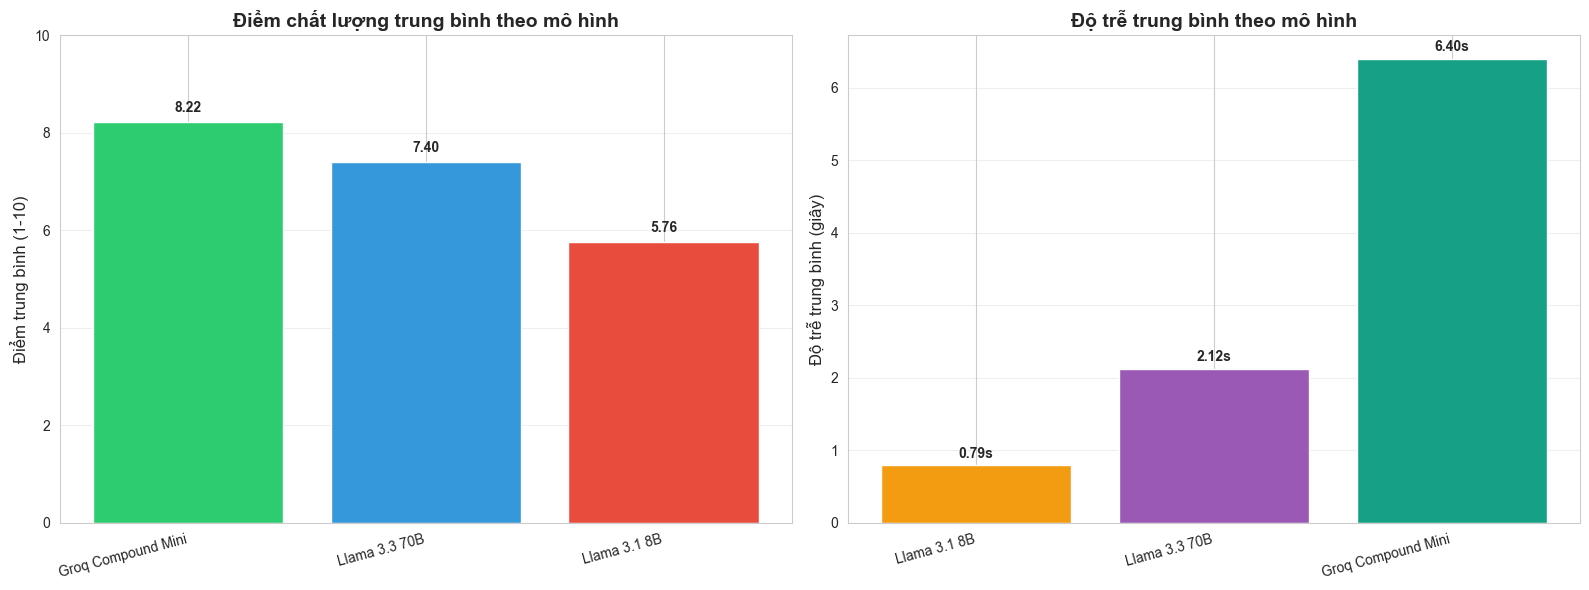

✅ Đã lưu biểu đồ tổng hợp vào 'evaluation\evaluation_summary.png'


In [114]:
# 1. Biểu đồ cột: Điểm trung bình theo mô hình
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Average Score
avg_scores = df_results.groupby('model_name')['score'].mean().sort_values(ascending=False)

axes[0].bar(range(len(avg_scores)), avg_scores.values, color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_xticks(range(len(avg_scores)))
axes[0].set_xticklabels(avg_scores.index, rotation=15, ha='right')
axes[0].set_ylabel('Điểm trung bình (1-10)', fontsize=12)
axes[0].set_title('Điểm chất lượng trung bình theo mô hình', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 10)
axes[0].grid(axis='y', alpha=0.3)

# Thêm giá trị lên cột
for i, v in enumerate(avg_scores.values):
    axes[0].text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')

# Chart 2: Average Latency
avg_latency = df_results.groupby('model_name')['latency_seconds'].mean().sort_values()

axes[1].bar(range(len(avg_latency)), avg_latency.values, color=['#f39c12', '#9b59b6', '#16a085'])
axes[1].set_xticks(range(len(avg_latency)))
axes[1].set_xticklabels(avg_latency.index, rotation=15, ha='right')
axes[1].set_ylabel('Độ trễ trung bình (giây)', fontsize=12)
axes[1].set_title('Độ trễ trung bình theo mô hình', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Thêm giá trị lên cột
for i, v in enumerate(avg_latency.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'evaluation_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Đã lưu biểu đồ tổng hợp vào '{os.path.join(EVAL_DIR, 'evaluation_summary.png')}'")

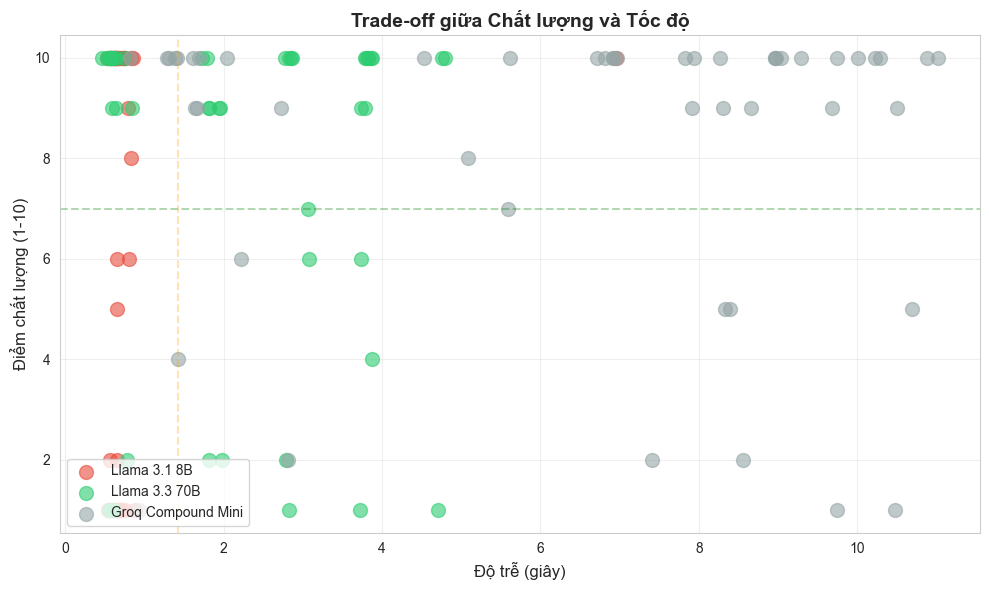

✅ Đã lưu scatter plot vào 'evaluation\score_vs_latency.png'


In [ ]:
# 2. Scatter plot: Score vs Latency (Trade-off)
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Llama 3.1 8B': '#e74c3c', 'Llama 3.3 70B': '#2ecc71', 'Groq Compound': '#3498db'}

for model_name in df_results['model_name'].unique():
    model_data = df_results[df_results['model_name'] == model_name]
    ax.scatter(
        model_data['latency_seconds'], 
        model_data['score'],
        label=model_name,
        alpha=0.6,
        s=100,
        color=colors.get(model_name, '#95a5a6')
    )

ax.set_xlabel('Độ trễ (giây)', fontsize=12)
ax.set_ylabel('Điểm chất lượng (1-10)', fontsize=12)
ax.set_title('Trade-off giữa Chất lượng và Tốc độ', fontsize=14, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

# Vẽ vùng lý tưởng (high score, low latency)
ax.axhline(y=7, color='green', linestyle='--', alpha=0.3, label='Ngưỡng tốt (≥7)')
ax.axvline(x=df_results['latency_seconds'].median(), color='orange', linestyle='--', alpha=0.3, label='Độ trễ trung vị')

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'score_vs_latency.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Đã lưu scatter plot vào '{os.path.join(EVAL_DIR, 'score_vs_latency.png')}'")

## 11. Error Analysis
Phân tích các câu trả lời có điểm thấp để tìm pattern lỗi.

In [118]:
# Lọc các câu trả lời có điểm thấp (≤ 5)
low_score_cases = df_results[df_results['score'] <= 5].sort_values('score')

print(f"📉 Tổng số câu trả lời có điểm ≤ 5: {len(low_score_cases)}/{len(df_results)} ({len(low_score_cases)/len(df_results)*100:.1f}%)")
print("\n🔍 TOP 10 CÂU TRẢ LỜI ĐIỂM THẤP NHẤT:\n")
print("="*100)

for idx, row in low_score_cases.head(10).iterrows():
    print(f"\nCâu hỏi: {row['question']}")
    print(f"Mô hình: {row['model_name']} | Điểm: {row['score']}/10")
    print(f"Ground Truth: {row['ground_truth']}")
    print(f"AI trả lời: {row['generated_answer']}")
    print(f"Lý do điểm thấp: {row['reasoning']}")
    print("-"*100)

📉 Tổng số câu trả lời có điểm ≤ 5: 46/150 (30.7%)

🔍 TOP 10 CÂU TRẢ LỜI ĐIỂM THẤP NHẤT:


Câu hỏi: Sinh viên khóa 2023 có thể nộp chứng chỉ IELTS để miễn học phần tiếng Anh trong bao lâu?
Mô hình: Llama 3.3 70B | Điểm: 1/10
Ground Truth: Sinh viên chỉ được sử dụng chứng chỉ quy đổi sang các học phần Kỹ năng giao tiếp tiếng Anh trong 07 học kỳ đầu tiên.
AI trả lời: Tôi không tìm thấy thông tin này trong tài liệu.
Lý do điểm thấp: AI không cung cấp thông tin đúng; trả lời rằng không tìm thấy thông tin trong khi Ground Truth đã nêu rõ thời gian 07 học kỳ đầu tiên.
----------------------------------------------------------------------------------------------------

Câu hỏi: Mức điểm TOEIC 4 kỹ năng để được miễn học phần Kỹ năng giao tiếp tiếng Anh 1 là bao nhiêu?
Mô hình: Llama 3.1 8B | Điểm: 1/10
Ground Truth: Mức điểm TOEIC (4 kỹ năng) để miễn Kỹ năng giao tiếp tiếng Anh 1 là 385-785.
AI trả lời: Tôi không tìm thấy thông tin này trong tài liệu.
Lý do điểm thấp: AI không cung cấp đáp án đ

## 12. Final Summary & Recommendations

In [120]:
print("\n" + "="*100)
print("📊 KẾT LUẬN ĐÁNH GIÁ RAG PIPELINE")
print("="*100)

# Tổng quan
total_questions = len(test_dataset)
total_tests = len(df_results)
avg_score_all = df_results['score'].mean()
avg_latency_all = df_results['latency_seconds'].mean()

print(f"\n✅ Đã hoàn thành {total_tests} lần test với {len(llm_models)} mô hình trên {total_questions} câu hỏi.")
print(f"📈 Điểm trung bình tổng thể: {avg_score_all:.2f}/10")
print(f"⏱️ Độ trễ trung bình: {avg_latency_all:.2f} giây")

# Xếp hạng
print("\n🏆 XẾP HẠNG MÔ HÌNH:\n")
ranking = summary_table.reset_index()
for idx, row in ranking.iterrows():
    print(f"{idx+1}. {row['model_name']}")
    print(f"   - Điểm TB: {row['Điểm trung bình']:.2f}/10")
    print(f"   - Độ trễ TB: {row['Độ trễ TB (giây)']:.2f}s")

# Khuyến nghị
print("\n💡 KHUYẾN NGHỊ:")
best_quality_model = ranking.iloc[0]['model_name']
fastest_model = ranking.sort_values('Độ trễ TB (giây)').iloc[0]['model_name']

print(f"   - Nếu ưu tiên CHẤT LƯỢNG: Dùng '{best_quality_model}'")
print(f"   - Nếu ưu tiên TỐC ĐỘ: Dùng '{fastest_model}'")

# Tính balance score (normalized quality / normalized latency)
ranking['quality_norm'] = ranking['Điểm trung bình'] / 10
ranking['speed_norm'] = 1 - (ranking['Độ trễ TB (giây)'] / ranking['Độ trễ TB (giây)'].max())
ranking['balance_score'] = (ranking['quality_norm'] + ranking['speed_norm']) / 2
best_balance_model = ranking.sort_values('balance_score', ascending=False).iloc[0]['model_name']

print(f"   - Nếu cần CÂN BẰNG: Dùng '{best_balance_model}'")

print("\n" + "="*100)
print("✅ Hoàn tất toàn bộ quá trình đánh giá RAG Pipeline!")
print("="*100)


📊 KẾT LUẬN ĐÁNH GIÁ RAG PIPELINE

✅ Đã hoàn thành 150 lần test với 3 mô hình trên 50 câu hỏi.
📈 Điểm trung bình tổng thể: 7.13/10
⏱️ Độ trễ trung bình: 3.11 giây

🏆 XẾP HẠNG MÔ HÌNH:

1. Groq Compound Mini
   - Điểm TB: 8.22/10
   - Độ trễ TB: 6.40s
2. Llama 3.3 70B
   - Điểm TB: 7.40/10
   - Độ trễ TB: 2.12s
3. Llama 3.1 8B
   - Điểm TB: 5.76/10
   - Độ trễ TB: 0.79s

💡 KHUYẾN NGHỊ:
   - Nếu ưu tiên CHẤT LƯỢNG: Dùng 'Groq Compound Mini'
   - Nếu ưu tiên TỐC ĐỘ: Dùng 'Llama 3.1 8B'
   - Nếu cần CÂN BẰNG: Dùng 'Llama 3.1 8B'

✅ Hoàn tất toàn bộ quá trình đánh giá RAG Pipeline!


## 13. So sánh Embedding Models: MiniLM-L12-v2 vs Alibaba GTE
So sánh hiệu quả giữa 2 mô hình embedding:
- **MiniLM-L12-v2**: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 (384 dimensions)
- **Alibaba GTE**: Alibaba-NLP/gte-multilingual-base (768 dimensions)

In [121]:
# Cell 1: Load và so sánh 2 file kết quả

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Đường dẫn file
MINILM_CSV = os.path.join(EVAL_DIR, "evaluation_results_MiniLM-L12-v2.csv")
ALIBABA_CSV = os.path.join(EVAL_DIR, "evaluation_results_Alibaba.csv")

# Load data
df_minilm = pd.read_csv(MINILM_CSV, encoding='utf-8-sig')
df_alibaba = pd.read_csv(ALIBABA_CSV, encoding='utf-8-sig')

# Thêm cột embedding_model để phân biệt
df_minilm['embedding_model'] = 'MiniLM-L12-v2'
df_alibaba['embedding_model'] = 'Alibaba-GTE'

# Gộp 2 dataframe
df_combined = pd.concat([df_minilm, df_alibaba], ignore_index=True)

print("📊 THỐNG KÊ SƠ BỘ")
print("="*60)
print(f"MiniLM-L12-v2: {len(df_minilm)} bản ghi, Điểm TB = {df_minilm['score'].mean():.2f}")
print(f"Alibaba-GTE:   {len(df_alibaba)} bản ghi, Điểm TB = {df_alibaba['score'].mean():.2f}")
print("="*60)

📊 THỐNG KÊ SƠ BỘ
MiniLM-L12-v2: 150 bản ghi, Điểm TB = 5.07
Alibaba-GTE:   150 bản ghi, Điểm TB = 7.13


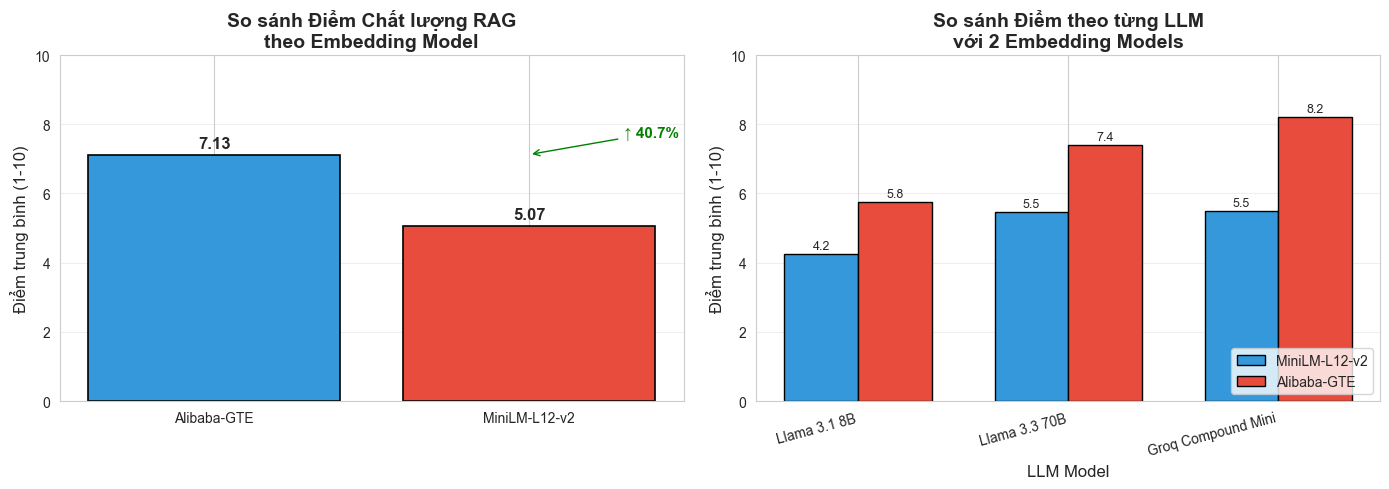

✅ Đã lưu biểu đồ so sánh vào 'evaluation\embedding_comparison.png'


In [122]:
# Cell 2: Biểu đồ so sánh tổng quan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Điểm trung bình tổng thể ---
embedding_scores = df_combined.groupby('embedding_model')['score'].mean()

colors = ['#3498db', '#e74c3c']
bars1 = axes[0].bar(embedding_scores.index, embedding_scores.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('Điểm trung bình (1-10)', fontsize=12)
axes[0].set_title('So sánh Điểm Chất lượng RAG\ntheo Embedding Model', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 10)
axes[0].grid(axis='y', alpha=0.3)

# Thêm giá trị lên cột
for bar, score in zip(bars1, embedding_scores.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                 f'{score:.2f}', ha='center', fontweight='bold', fontsize=12)

# Tính % cải thiện
improvement = ((embedding_scores['Alibaba-GTE'] - embedding_scores['MiniLM-L12-v2']) 
               / embedding_scores['MiniLM-L12-v2'] * 100)
axes[0].annotate(f'↑ {improvement:.1f}%', 
                 xy=(1, embedding_scores['Alibaba-GTE']), 
                 xytext=(1.3, embedding_scores['Alibaba-GTE'] + 0.5),
                 fontsize=11, color='green', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='green'))

# --- Chart 2: Grouped Bar - So sánh theo từng LLM ---
llm_models = df_combined['model_name'].unique()
x = np.arange(len(llm_models))
width = 0.35

scores_minilm = df_minilm.groupby('model_name')['score'].mean()
scores_alibaba = df_alibaba.groupby('model_name')['score'].mean()

bars2 = axes[1].bar(x - width/2, [scores_minilm.get(m, 0) for m in llm_models], 
                    width, label='MiniLM-L12-v2', color='#3498db', edgecolor='black')
bars3 = axes[1].bar(x + width/2, [scores_alibaba.get(m, 0) for m in llm_models], 
                    width, label='Alibaba-GTE', color='#e74c3c', edgecolor='black')

axes[1].set_xlabel('LLM Model', fontsize=12)
axes[1].set_ylabel('Điểm trung bình (1-10)', fontsize=12)
axes[1].set_title('So sánh Điểm theo từng LLM\nvới 2 Embedding Models', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(llm_models, rotation=15, ha='right')
axes[1].set_ylim(0, 10)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

# Thêm giá trị lên cột
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, 
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, 
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'embedding_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Đã lưu biểu đồ so sánh vào '{os.path.join(EVAL_DIR, 'embedding_comparison.png')}'")